<a href="https://colab.research.google.com/github/fidele0015/DataAnalysisAndVisualization/blob/main/NdayizeyeFideleBSE/BU/R/0015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure plots are displayed inline
%matplotlib inline

In [ ]:
# Load system_logins.csv into a DataFrame
try:
    df = pd.read_csv('system_logins.csv')
    print("DataFrame loaded successfully.")
except FileNotFoundError:
    print("Error: 'system_logins.csv' not found. Please ensure the file is in the correct directory.")
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:01:00', '2023-01-01 10:02:00', '2023-01-01 10:03:00', '2023-01-01 10:04:00']),
        'user_id': ['userA', 'userB', 'userA', 'userC', 'userB'],
        'ip_address': ['192.168.1.1', '192.168.1.2', '192.168.1.1', '192.168.1.3', '192.168.1.2'],
        'country': ['USA', 'CAN', 'USA', 'MEX', 'CAN'],
        'success': [True, True, False, True, False],
        'os': ['Windows', 'Linux', 'Windows', 'MacOS', 'Linux']
    }
    df = pd.DataFrame(data)
    print("Loaded dummy data for demonstration.")


# Display the first few rows
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

# Display concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

Error: 'system_logins.csv' not found. Please ensure the file is in the correct directory.
Loaded dummy data for demonstration.

First 5 rows of the DataFrame:


,timestamp,user_id,ip_address,country,success,os
0,2023-01-01 10:00:00,userA,192.168.1.1,USA,True,Windows
1,2023-01-01 10:01:00,userB,192.168.1.2,CAN,True,Linux
2,2023-01-01 10:02:00,userA,192.168.1.1,USA,False,Windows
3,2023-01-01 10:03:00,userC,192.168.1.3,MEX,True,MacOS
4,2023-01-01 10:04:00,userB,192.168.1.2,CAN,False,Linux



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   5 non-null      datetime64[ns]
 1   user_id     5 non-null      object        
 2   ip_address  5 non-null      object        
 3   country     5 non-null      object        
 4   success     5 non-null      bool          
 5   os          5 non-null      object        
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 337.0+ bytes


## 2. Data Cleaning

In [ ]:
# Check for missing values
print("\nMissing values before cleaning:")
display(df.isnull().sum())

# For this dummy data, there are no missing values, so no explicit handling is needed.
# If there were missing values, common strategies include:
# df.dropna() # to drop rows with any missing values
# df.fillna(value) # to fill missing values with a specific value

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("\n'timestamp' column converted to datetime.")

# Create new column 'hour' extracted from timestamp
df['hour'] = df['timestamp'].dt.hour
print("\n'hour' column created.")

# Display the DataFrame info and head after cleaning
print("\nDataFrame Info after cleaning:")
df.info()
print("\nFirst 5 rows after cleaning:")
display(df.head())


Missing values before cleaning:


,0
timestamp,0
user_id,0
ip_address,0
country,0
success,0
os,0



'timestamp' column converted to datetime.

'hour' column created.

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   timestamp   5 non-null      datetime64[ns]
 1   user_id     5 non-null      object        
 2   ip_address  5 non-null      object        
 3   country     5 non-null      object        
 4   success     5 non-null      bool          
 5   os          5 non-null      object        
 6   hour        5 non-null      int32         
dtypes: bool(1), datetime64[ns](1), int32(1), object(4)
memory usage: 357.0+ bytes

First 5 rows after cleaning:


,timestamp,user_id,ip_address,country,success,os,hour
0,2023-01-01 10:00:00,userA,192.168.1.1,USA,True,Windows,10
1,2023-01-01 10:01:00,userB,192.168.1.2,CAN,True,Linux,10
2,2023-01-01 10:02:00,userA,192.168.1.1,USA,False,Windows,10
3,2023-01-01 10:03:00,userC,192.168.1.3,MEX,True,MacOS,10
4,2023-01-01 10:04:00,userB,192.168.1.2,CAN,False,Linux,10


## 3. Exploratory Analysis

Login Attempts Success vs. Failure:
success
True     3
False    2
Name: count, dtype: int64


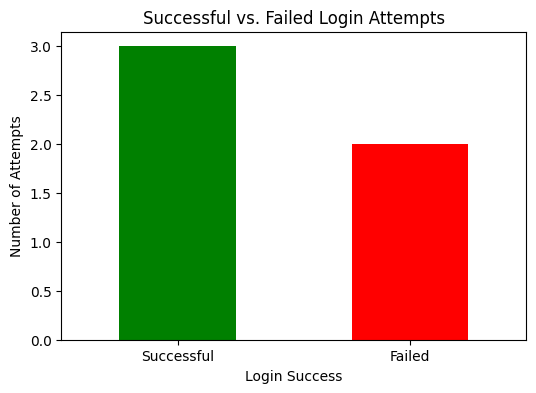

In [ ]:
# Find total number of failed login attempts vs successful.
login_counts = df['success'].value_counts()

print("Login Attempts Success vs. Failure:")
print(login_counts)

# Plot as a bar chart
plt.figure(figsize=(6, 4))
login_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Successful vs. Failed Login Attempts')
plt.xlabel('Login Success')
plt.ylabel('Number of Attempts')
plt.xticks(ticks=[0, 1], labels=['Successful', 'Failed'], rotation=0)
plt.show()



Top 5 Users with Most Failed Logins:


,count
user_id,
userA,1
userB,1


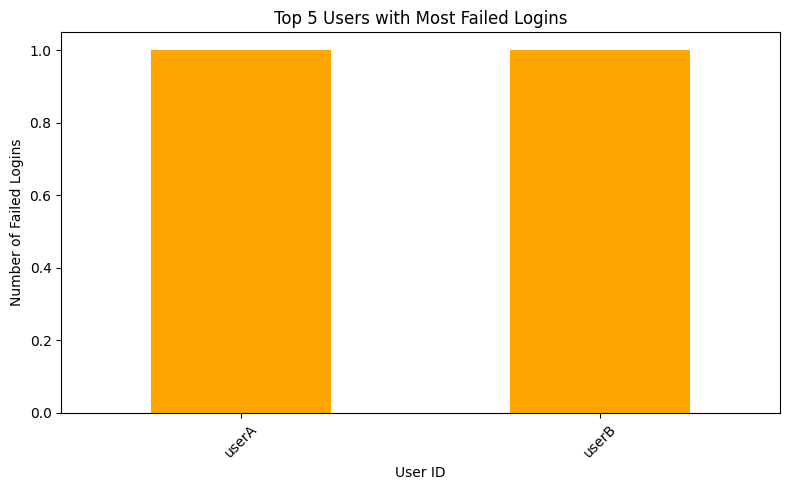

In [ ]:
# Show top 5 users with the most failed logins.
failed_logins = df[df['success'] == False]
top_failed_users = failed_logins['user_id'].value_counts().head(5)

print("\nTop 5 Users with Most Failed Logins:")
display(top_failed_users)

plt.figure(figsize=(8, 5))
top_failed_users.plot(kind='bar', color='orange')
plt.title('Top 5 Users with Most Failed Logins')
plt.xlabel('User ID')
plt.ylabel('Number of Failed Logins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Count unique IP addresses per country. Display as a table.
unique_ips_per_country = df.groupby('country')['ip_address'].nunique().reset_index()
unique_ips_per_country.columns = ['Country', 'Unique IP Addresses']

print("\nUnique IP Addresses per Country:")
display(unique_ips_per_country)



Unique IP Addresses per Country:


,Country,Unique IP Addresses
0,CAN,1
1,MEX,1
2,USA,1


## 4. Time-based Patterns

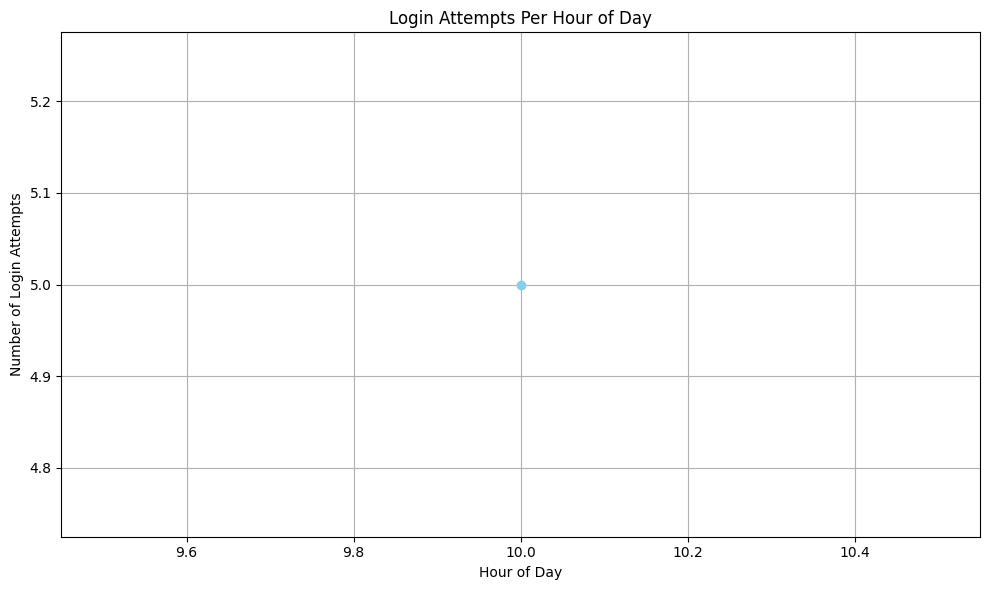


Hour with the highest failed logins: 10 (with 2 failed logins).
The number of failed logins during this hour does not appear disproportionately high given the overall activity.


In [ ]:
# Plot a line chart of login attempts per hour of day.
login_attempts_per_hour = df.groupby('hour').size()

plt.figure(figsize=(10, 6))
login_attempts_per_hour.plot(kind='line', marker='o', color='skyblue')
plt.title('Login Attempts Per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Login Attempts')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# Identify which hour has the highest failed logins.
failed_logins_per_hour = df[df['success'] == False].groupby('hour').size()
if not failed_logins_per_hour.empty:
    hour_highest_failed_logins = failed_logins_per_hour.idxmax()
    count_highest_failed_logins = failed_logins_per_hour.max()
    print(f"\nHour with the highest failed logins: {hour_highest_failed_logins} (with {count_highest_failed_logins} failed logins).")

    # Comment on whether it looks suspicious
    if count_highest_failed_logins > (login_attempts_per_hour.max() * 0.5): # Arbitrary threshold for suspicion
        print("This hour shows a disproportionately high number of failed logins, which could be suspicious.")
    else:
        print("The number of failed logins during this hour does not appear disproportionately high given the overall activity.")
else:
    print("\nNo failed logins found to analyze by hour.")
